# Notebook 01
## Waveform Generation

Goal

Generate transmit waveform for ZZB simulation.

Waveforms

- LFM Chirp
- OFDM (future)
- Zadoff-Chu (future)
- m-sequence (future)

Current Task

Generate one LFM waveform and verify

- waveform
- spectrum
- autocorrelation

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import chirp
from scipy.signal import correlate

In [13]:
fs = 20e6              # Sampling frequency (Hz)

T = 20e-6              # Pulse duration

B = 5e6                # Chirp bandwidth

f0 = -B/2              # Start frequency

f1 = B/2               # End frequency

In [14]:
k = B / T

N = int(T * fs)

t = np.arange(N) / fs

t = t - T/2

s = np.exp(1j * np.pi * k * t**2)

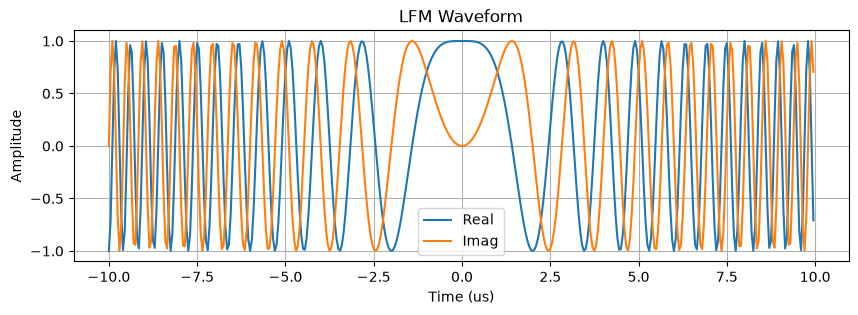

In [15]:
plt.figure(figsize=(10,3))

plt.plot(t * 1e6, np.real(s), label="Real")
plt.plot(t * 1e6, np.imag(s), label="Imag")
plt.legend()

plt.xlabel("Time (us)")
plt.ylabel("Amplitude")

plt.title("LFM Waveform")

plt.grid(True)

plt.show()

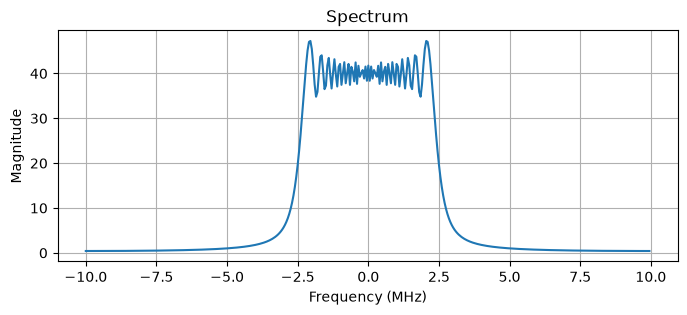

In [16]:
S = np.fft.fftshift(np.fft.fft(s))

freq = np.fft.fftshift(np.fft.fftfreq(len(s),1/fs))

plt.figure(figsize=(8,3))

plt.plot(freq/1e6,np.abs(S))

plt.xlabel("Frequency (MHz)")

plt.ylabel("Magnitude")

plt.title("Spectrum")

plt.grid(True)

plt.show()

In [17]:
R = correlate(s,s,mode='full')

lags = np.arange(-len(s)+1,len(s))

d:\Anaconda\envs\zzb\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\Anaconda\envs\zzb\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


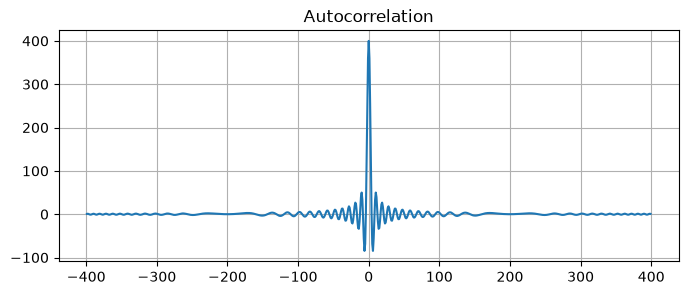

In [18]:
plt.figure(figsize=(8,3))

plt.plot(lags,R)

plt.title("Autocorrelation")

plt.grid(True)

plt.show()

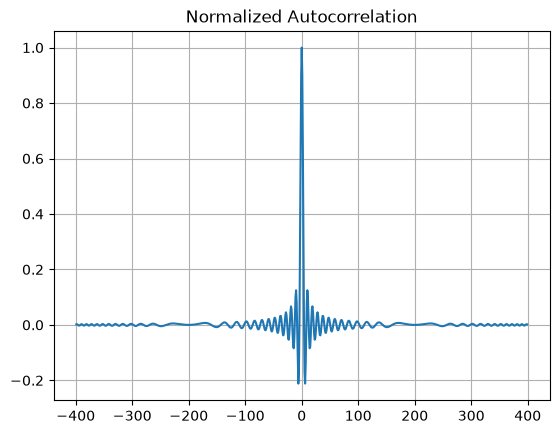

In [19]:
R_normalized = R/np.max(np.abs(R))

plt.plot(lags,R_normalized)

plt.title("Normalized Autocorrelation")

plt.grid(True)

plt.show()